In [1]:
%pip install implicit sentence-transformers threadpoolctl -q

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from collections import Counter, defaultdict
from scipy.sparse import csr_matrix, coo_matrix
from implicit.als import AlternatingLeastSquares
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm
import random
import gc
import torch

import threadpoolctl
threadpoolctl.threadpool_limits(1, "blas")

# Paths
DATA_PATH = "../data/final/all_reviews_full_with_genres.parquet"
GAMES_PATH = "../data/intermediate/steam_games_with_parsed_genres.parquet"
OUTPUT_DIR = "../data/models"
CHECKPOINT_DIR = "../data/models/checkpoints/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Checking for GPU availability
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Detected: {gpu_name} ({gpu_memory:.1f} GB)")
else:
    print(" No GPU detected - will use CPU")

print(f" CPUs available: {os.cpu_count()}")
print(f" GPU available: {torch.cuda.is_available()}")

Note: you may need to restart the kernel to use updated packages.
GPU Detected: NVIDIA GeForce GTX 1080 Ti (10.9 GB)
 CPUs available: 64
 GPU available: True


In [2]:
# Expanded word lists for game reviews
POSITIVE_WORDS = {
    'amazing', 'awesome', 'best', 'excellent', 'fantastic', 'fun', 'good', 'great',
    'love', 'perfect', 'recommended', 'wonderful', 'enjoyed', 'favorite', 'like',
    'masterpiece', 'brilliant', 'outstanding', 'addictive', 'beautiful', 'epic',
    'solid', 'nice', 'enjoy', 'loved', 'impressed', 'recommend', 'better', 
    'entertaining', 'engaging', 'immersive', 'polished', 'smooth', 'balanced',
    'creative', 'unique', 'innovative', 'satisfying', 'challenging', 'rewarding'
}

NEGATIVE_WORDS = {
    'bad', 'boring', 'broken', 'buggy', 'disappointing', 'garbage', 'horrible',
    'poor', 'terrible', 'waste', 'worst', 'awful', 'hate', 'refund', 'unplayable',
    'crash', 'glitchy', 'frustrating', 'repetitive', 'underwhelming', 'mediocre',
    'bland', 'clunky', 'laggy', 'unfinished', 'overpriced', 'grindy', 'tedious',
    'unfair', 'unbalanced', 'confusing', 'outdated', 'annoying', 'disappointing',
    'mess', 'disaster', 'avoid', 'skip', 'regret', 'useless'
}

def get_sentiment_score(text):
    if not text or len(text.strip()) < 10:
        return 0.0
    
    text_lower = text.lower()
    words = text_lower.split()
    
    pos_count = sum(1 for word in words if word in POSITIVE_WORDS)
    neg_count = sum(1 for word in words if word in NEGATIVE_WORDS)
    
    total = pos_count + neg_count
    if total == 0:
        return 0.0

    return (pos_count - neg_count) / total

test_reviews = [
    "This game is absolutely amazing! Best purchase ever.",
    "Terrible game, full of bugs and crashes. Total waste of money.",
    "It's okay, nothing special but not bad either."
]

for review in test_reviews:
    score = get_sentiment_score(review)
    sentiment = "positive" if score > 0.2 else "negative" if score < -0.2 else "neutral"
    print(f"  Score: {score:+.3f} ({sentiment}) | '{review[:50]}...'")



  Score: +1.000 (positive) | 'This game is absolutely amazing! Best purchase eve...'
  Score: -1.000 (negative) | 'Terrible game, full of bugs and crashes. Total was...'
  Score: -1.000 (negative) | 'It's okay, nothing special but not bad either....'


In [3]:
import time

def save_checkpoint(name, data):
    checkpoint_path = f"{CHECKPOINT_DIR}/{name}.pkl"
    start = time.time()
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(data, f)
    file_size = os.path.getsize(checkpoint_path) / (1024**2)
    elapsed = time.time() - start
    print(f" Saved: {name} ({file_size:.2f} MB in {elapsed:.1f}s)")

def load_checkpoint(name):
    checkpoint_path = f"{CHECKPOINT_DIR}/{name}.pkl"
    if os.path.exists(checkpoint_path):
        start = time.time()
        with open(checkpoint_path, 'rb') as f:
            data = pickle.load(f)
        elapsed = time.time() - start
        print(f" Loaded: {name} (in {elapsed:.1f}s)")
        return data
    return None

print(" Checkpoint system ready")

 Checkpoint system ready


In [4]:
#Sampling
SAMPLE_SIZE = 20000  
MIN_REVIEWS = 5

sampled_users = load_checkpoint('sampled_users_20k')

if sampled_users is None:
    print(f"Sampling {SAMPLE_SIZE:,} users (MIN_REVIEWS={MIN_REVIEWS})")
    start_time = time.time()
    
    pf = pq.ParquetFile(DATA_PATH)
    user_counts = Counter()

    for rg in tqdm(range(pf.num_row_groups), desc="Counting users"):
        tbl = pf.read_row_group(rg, columns=["author_steamid"])
        user_counts.update(tbl["author_steamid"].to_pylist())
    
    elapsed = time.time() - start_time
    print(f" Counted {len(user_counts):,} users in {elapsed/60:.1f} min")
    
    # Filtering and sampling out valid samples
    eligible_users = [u for u, c in user_counts.items() if c >= MIN_REVIEWS]
    print(f" Eligible users (>={MIN_REVIEWS} reviews): {len(eligible_users):,}")
    
    sampled_users = set(random.sample(eligible_users, min(SAMPLE_SIZE, len(eligible_users))))

    save_checkpoint('sampled_users_20k', sampled_users)
    
    print(f" Sampled {len(sampled_users):,} users")
    print(f" Sampling rate: {len(sampled_users)/len(user_counts)*100:.2f}% of total users")
else:
    print(f" Loaded {len(sampled_users):,} users from checkpoint")

 Loaded: sampled_users_20k (in 0.0s)
 Loaded 20,000 users from checkpoint


In [5]:
# Load Reviews for Sampled Users
user_reviews = load_checkpoint('user_reviews_20k')

if user_reviews is None:
    print(f"Loading reviews for {len(sampled_users):,} users")
    start_time = time.time()
    
    user_reviews = defaultdict(list)
    pf = pq.ParquetFile(DATA_PATH)

    #Process in larger batches, reducing overheads
    total_loaded = 0
    
    for rg in tqdm(range(pf.num_row_groups), desc="Loading reviews"):
        tbl = pf.read_row_group(rg, columns=[
            "author_steamid", "appid", "timestamp_created", 
            "review", "voted_up", "weighted_vote_score", "votes_up"
        ])

        #filtering out for sampled users only
        df = tbl.to_pandas()
        df_filtered = df[df['author_steamid'].isin(sampled_users)]
        
        for _, row in df_filtered.iterrows():
            user_reviews[row['author_steamid']].append({
                'appid': row['appid'],
                'timestamp': row['timestamp_created'],
                'review_text': row['review'] if pd.notna(row['review']) else "",
                'voted_up': row['voted_up'],
                'weighted_vote_score': row['weighted_vote_score'] if pd.notna(row['weighted_vote_score']) else 0.0,
                'votes_up': row['votes_up'] if pd.notna(row['votes_up']) else 0
            })
        
        total_loaded += len(df_filtered)

        if rg % 20 == 0 and total_loaded > 0:
            elapsed_so_far = time.time() - start_time
            avg_per_rg = elapsed_so_far / (rg + 1)
            remaining_rgs = pf.num_row_groups - rg
            eta_min = (avg_per_rg * remaining_rgs) / 60
            print(f"  Loaded {total_loaded:,} reviews | ETA: {eta_min:.1f} min", end='\r')
    
    elapsed = time.time() - start_time
    total_reviews = sum(len(r) for r in user_reviews.values())
    
    save_checkpoint('user_reviews_20k', dict(user_reviews))
    
    print(f" Loaded {total_reviews:,} reviews in {elapsed/60:.1f} min")
    print(f" Speed: {total_reviews/elapsed:.0f} reviews/sec")
    print(f" Avg: {total_reviews/len(user_reviews):.1f} reviews/user")
else:
    user_reviews = defaultdict(list, user_reviews)
    total_reviews = sum(len(r) for r in user_reviews.values())
    print(f" Loaded {total_reviews:,} reviews from checkpoint in <1 sec")
    print(f" Avg: {total_reviews/len(user_reviews):.1f} reviews/user")

 Loaded: user_reviews_20k (in 1.1s)
 Loaded 231,836 reviews from checkpoint in <1 sec
 Avg: 11.6 reviews/user


In [6]:
#Train/Test splits

split_data = load_checkpoint('train_test_split_20k')
if split_data is None:
    print("Creating temporal train/test splits (80/20)")
    
    train_reviews_by_user = {}
    test_reviews_by_user = {}
    users_final = []
    
    for u, reviews in tqdm(user_reviews.items(), desc="Splitting"):
        if len(reviews) < 2:
            continue
        
        # Temporal split (sorted by timestamp)
        reviews.sort(key=lambda x: x['timestamp'])
        split_idx = max(1, int(0.8 * len(reviews)))
        train = reviews[:split_idx]
        test = reviews[split_idx:]
        
        if train and test:
            train_reviews_by_user[u] = train
            test_reviews_by_user[u] = test
            users_final.append(u)
    
    # Extracting items for evaluation
    train_items_by_user = {u: [r['appid'] for r in revs] 
                           for u, revs in train_reviews_by_user.items()}
    test_items_by_user = {u: {r['appid'] for r in revs} 
                          for u, revs in test_reviews_by_user.items()}
    
    save_checkpoint('train_test_split_20k', {
        'train_reviews_by_user': train_reviews_by_user,
        'test_reviews_by_user': test_reviews_by_user,
        'users_final': users_final,
        'train_items_by_user': train_items_by_user,
        'test_items_by_user': test_items_by_user
    })
    
    n_train_reviews = sum(len(r) for r in train_reviews_by_user.values())
    n_test_reviews = sum(len(r) for r in test_reviews_by_user.values())
    
    print(f" Created splits for {len(users_final):,} users")
    print(f"  Train reviews: {n_train_reviews:,}")
    print(f"  Test reviews:  {n_test_reviews:,}")
    print(f"  Avg train/user: {n_train_reviews/len(users_final):.1f}")
    print(f"  Avg test/user:  {n_test_reviews/len(users_final):.1f}")
else:
    train_reviews_by_user = split_data['train_reviews_by_user']
    test_reviews_by_user = split_data['test_reviews_by_user']
    users_final = split_data['users_final']
    train_items_by_user = split_data['train_items_by_user']
    test_items_by_user = split_data['test_items_by_user']
    
    print(f" Loaded splits from checkpoint")
    print(f"  Users: {len(users_final):,}")
    print(f"  Train reviews: {sum(len(r) for r in train_reviews_by_user.values()):,}")
    print(f"  Test reviews:  {sum(len(r) for r in test_reviews_by_user.values()):,}")


 Loaded: train_test_split_20k (in 1.0s)
 Loaded splits from checkpoint
  Users: 20,000
  Train reviews: 177,894
  Test reviews:  53,942


In [7]:
sentiment_data = load_checkpoint('sentiment_20k')

if sentiment_data is None:
    user_sentiment_scores = {}
    
    for u in tqdm(users_final, desc="Sentiment"):
        train_revs = train_reviews_by_user[u]
        sentiments = []
        
        for rev in train_revs:
            sentiment = get_sentiment_score(rev['review_text']) 
            sentiments.append({
                'appid': rev['appid'],
                'sentiment': sentiment,
                'voted_up': rev['voted_up'],
                'weighted_vote_score': rev['weighted_vote_score'],
                'votes_up': rev['votes_up']
            })
        
        user_sentiment_scores[u] = sentiments
    
    print(f" Sentiment extraction complete for {len(user_sentiment_scores):,} users")
    
    # Calculating average sentiment per user
    avg_user_sentiment = {u: np.mean([s['sentiment'] for s in scores]) 
                          for u, scores in user_sentiment_scores.items()}
    
    # Building item sentiment profiles
    item_sentiments = defaultdict(list)
    item_voted_up_ratio = defaultdict(list)
    
    for u, sentiments in user_sentiment_scores.items():
        for s in sentiments:
            item_sentiments[s['appid']].append(s['sentiment'])
            item_voted_up_ratio[s['appid']].append(1 if s['voted_up'] else 0)
    
    item_avg_sentiment = {appid: np.mean(scores) for appid, scores in item_sentiments.items()}
    item_positive_ratio = {appid: np.mean(scores) for appid, scores in item_voted_up_ratio.items()}
    
    # Saving Checkpoint
    save_checkpoint('sentiment_20k', {
        'avg_user_sentiment': avg_user_sentiment,
        'item_avg_sentiment': item_avg_sentiment,
        'item_positive_ratio': item_positive_ratio,
        'user_sentiment_scores': user_sentiment_scores
    })
    

    print("Sentiment Analysis Summary")
    print(f"Average user sentiment: {np.mean(list(avg_user_sentiment.values())):.3f}")
    print(f"  Min: {min(avg_user_sentiment.values()):.3f}")
    print(f"  Max: {max(avg_user_sentiment.values()):.3f}")
    print(f"  Std: {np.std(list(avg_user_sentiment.values())):.3f}")
else:
    # Load from checkpoint
    avg_user_sentiment = sentiment_data['avg_user_sentiment']
    item_avg_sentiment = sentiment_data['item_avg_sentiment']
    item_positive_ratio = sentiment_data['item_positive_ratio']
    user_sentiment_scores = sentiment_data['user_sentiment_scores']
    print(f" Loaded sentiment data from checkpoint")
    print(f"  Users: {len(avg_user_sentiment):,}")
    print(f"  Items: {len(item_avg_sentiment):,}")

 Loaded: sentiment_20k (in 0.1s)
 Loaded sentiment data from checkpoint
  Users: 20,000
  Items: 16,388


In [8]:
# Calculaating average sentiment from all reviews per game
item_sentiments = defaultdict(list)
item_voted_up_ratio = defaultdict(list)
item_vote_scores = defaultdict(list)

for u, sentiments in user_sentiment_scores.items():
    for s in sentiments:
        item_sentiments[s['appid']].append(s['sentiment'])
        item_voted_up_ratio[s['appid']].append(1 if s['voted_up'] else 0)
        item_vote_scores[s['appid']].append(s['weighted_vote_score'])

# Calculating averages
item_avg_sentiment = {appid: np.mean(scores) for appid, scores in item_sentiments.items()}
item_positive_ratio = {appid: np.mean(scores) for appid, scores in item_voted_up_ratio.items()}
item_avg_helpfulness = {appid: np.mean(scores) for appid, scores in item_vote_scores.items()}

print(f" Built sentiment profiles for {len(item_avg_sentiment):,} items")
print(f" Avg item sentiment: {np.mean(list(item_avg_sentiment.values())):.3f}")
print(f" Avg positive ratio: {np.mean(list(item_positive_ratio.values())):.3f}")
print(f" Avg helpfulness score: {np.mean(list(item_avg_helpfulness.values())):.3f}")

# Distribution
sentiment_values = list(item_avg_sentiment.values())
pos_ratio_values = list(item_positive_ratio.values())

print(f"  Sentiment distribution:")
print(f"  Very negative (<-0.5): {sum(1 for s in sentiment_values if s < -0.5):,} items")
print(f"  Negative (-0.5 to 0):  {sum(1 for s in sentiment_values if -0.5 <= s < 0):,} items")
print(f"  Neutral (0 to 0):      {sum(1 for s in sentiment_values if s == 0):,} items")
print(f"  Positive (0 to 0.5):   {sum(1 for s in sentiment_values if 0 < s <= 0.5):,} items")
print(f"  Very positive (>0.5):  {sum(1 for s in sentiment_values if s > 0.5):,} items")

print(f"  Positive ratio distribution:")
print(f"  Mostly negative (<30%): {sum(1 for p in pos_ratio_values if p < 0.3):,} items")
print(f"  Mixed (30-70%):        {sum(1 for p in pos_ratio_values if 0.3 <= p <= 0.7):,} items")
print(f"  Mostly positive (>70%): {sum(1 for p in pos_ratio_values if p > 0.7):,} items")

 Built sentiment profiles for 16,388 items
 Avg item sentiment: 0.262
 Avg positive ratio: 0.780
 Avg helpfulness score: 0.302
  Sentiment distribution:
  Very negative (<-0.5): 183 items
  Negative (-0.5 to 0):  323 items
  Neutral (0 to 0):      7,327 items
  Positive (0 to 0.5):   5,322 items
  Very positive (>0.5):  3,233 items
  Positive ratio distribution:
  Mostly negative (<30%): 2,266 items
  Mixed (30-70%):        2,104 items
  Mostly positive (>70%): 12,018 items


In [9]:
#Building user/item indices
user2idx = {u: i for i, u in enumerate(train_items_by_user.keys())}
all_items = set()
for items in train_items_by_user.values():
    all_items.update(items)

item2idx = {a: i for i, a in enumerate(sorted(all_items))}
idx2item = {i: a for a, i in item2idx.items()}

print(f" Users: {len(user2idx):,}, Items: {len(item2idx):,}")

# Building sparse matrix
rows, cols, data = [], [], []
for u, items in train_items_by_user.items():
    ui = user2idx[u]
    for a in items:
        if a in item2idx:
            ii = item2idx[a]
            rows.append(ui)
            cols.append(ii)
            data.append(1)

X_train = coo_matrix((data, (rows, cols)), shape=(len(user2idx), len(item2idx)))
X_train_csr = X_train.tocsr()

print(f" Matrix: {X_train.shape}, sparsity: {100*(1-len(data)/(X_train.shape[0]*X_train.shape[1])):.2f}%")


# Training ALS
model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    random_state=42
)

model.fit(X_train_csr)
print("Model trained")

 Users: 20,000, Items: 16,388
 Matrix: (20000, 16388), sparsity: 99.95%


  0%|          | 0/15 [00:00<?, ?it/s]

Model trained


In [10]:
# Evaluating baseline CF model
def eval_model(model, X_user_item, users_final, user2idx, idx2item, 
               test_items_by_user, K=10):
    hits = total = hit_count = true_count = 0

    for u in users_final:
        true = test_items_by_user.get(u, set())
        if not true:
            continue

        ui = int(user2idx[u])
        
        ids, scores = model.recommend(
            np.array([ui]),
            X_user_item[[ui]],
            N=K,
            filter_already_liked_items=True
        )
        
        rec_items = {idx2item[int(i)] for i in ids[0]}
        inter = true & rec_items
        
        if inter:
            hits += 1
        hit_count += len(inter)
        true_count += len(true)
        total += 1

    hr = hits / total if total else 0.0
    recall = hit_count / true_count if true_count else 0.0
    precision = hit_count / (total * K) if total else 0.0
    
    return hr, recall, precision, total

hr_base, rec_base, prec_base, n_users = eval_model(
    model, X_train_csr, users_final, user2idx, idx2item, test_items_by_user, K=10
)

print(f"Baseline Results")
print(f"Users: {n_users:,}")
print(f"HR@10:     {hr_base:.6f}")
print(f"Recall@10: {rec_base:.6f}")
print(f"Precision@10: {prec_base:.6f}")

Baseline Results
Users: 20,000
HR@10:     0.115400
Recall@10: 0.046031
Precision@10: 0.012415


In [11]:
#Boosting items with sentiment aligned to user preference
def recommend_with_sentiment_boost(model, X_user_item, ui, user_id, 
                                   idx2item, item_avg_sentiment, avg_user_sentiment,
                                   N=10, oversample=200, boost_weight=0.3):

    # ALS recommendations
    ids, scores = model.recommend(
        np.array([ui]),
        X_user_item[[ui]],
        N=oversample,
        filter_already_liked_items=True
    )
    
    # User's average sentiment
    user_sent = avg_user_sentiment.get(user_id, 0.0)
    
    # Boost scores based on sentiment alignment
    boosted_scores = scores[0].copy()
    for i, item_idx in enumerate(ids[0]):
        appid = idx2item[int(item_idx)]
        item_sent = item_avg_sentiment.get(appid, 0.0)
        
        # Alignment bonus: higher if sentiments match
            # If user is positive (0.5) and item is positive (0.6), boost
            # If user is negative (-0.3) and item is negative (-0.2), also boost
        alignment = 1 - abs(user_sent - item_sent) 
        boosted_scores[i] *= (1 + boost_weight * alignment)
    
    # Re-rank by boosted scores
    top_indices = np.argsort(-boosted_scores)[:N]
    return [idx2item[int(ids[0][i])] for i in top_indices]

# Evaluating sentiment-enhanced model
def eval_sentiment_model(model, X_user_item, users_final, user2idx, idx2item,
                        test_items_by_user, avg_user_sentiment, item_avg_sentiment,
                        K=10, boost_weight=0.3):
    
    hits = total = hit_count = true_count = 0

    for u in users_final:
        true = test_items_by_user.get(u, set())
        if not true:
            continue
        
        ui = int(user2idx[u])
        
        rec_items = recommend_with_sentiment_boost(
            model, X_user_item, ui, u, idx2item, 
            item_avg_sentiment, avg_user_sentiment,
            N=K, boost_weight=boost_weight
        )
        rec_items_set = set(rec_items)
        
        inter = true & rec_items_set
        if inter:
            hits += 1
        hit_count += len(inter)
        true_count += len(true)
        total += 1

    hr = hits / total if total else 0.0
    recall = hit_count / true_count if true_count else 0.0
    precision = hit_count / (total * K) if total else 0.0
    
    return hr, recall, precision, total

# Testing different boost weights
boost_weights = [0.1, 0.3, 0.5, 0.7]
sentiment_results = []

for bw in boost_weights:
    print(f"Testing boost_weight={bw}")
    hr, rec, prec, n = eval_sentiment_model(
        model, X_train_csr, users_final, user2idx, idx2item,
        test_items_by_user, avg_user_sentiment, item_avg_sentiment,
        K=10, boost_weight=bw
    )
    
    sentiment_results.append({
        'boost_weight': bw,
        'HR@10': hr,
        'Recall@10': rec,
        'Precision@10': prec,
        'n_users': n
    })
    
    print(f"  HR@10:     {hr:.6f} (Δ={hr-hr_base:+.6f})")
    print(f"  Recall@10: {rec:.6f} (Δ={rec-rec_base:+.6f})")

results_df = pd.DataFrame(sentiment_results)
results_df.to_csv(f"{OUTPUT_DIR}/sentiment_boost_results.csv", index=False)
print(f" Saved results to {OUTPUT_DIR}/sentiment_boost_results.csv")

Testing boost_weight=0.1
  HR@10:     0.115700 (Δ=+0.000300)
  Recall@10: 0.046161 (Δ=+0.000130)
Testing boost_weight=0.3
  HR@10:     0.116050 (Δ=+0.000650)
  Recall@10: 0.046383 (Δ=+0.000352)
Testing boost_weight=0.5
  HR@10:     0.116450 (Δ=+0.001050)
  Recall@10: 0.046513 (Δ=+0.000482)
Testing boost_weight=0.7
  HR@10:     0.116450 (Δ=+0.001050)
  Recall@10: 0.046476 (Δ=+0.000445)
 Saved results to /home/brocchio/teams/z2/text_features//sentiment_boost_results.csv


In [12]:
# Alternative scenario: boost items with high "recommended" ratio
def recommend_with_votedUp_boost(model, X_user_item, ui, idx2item, 
                                 item_positive_ratio,
                                 N=10, oversample=200, boost_weight=0.5):

    #Boost items with high% of positive/thumbs up reviews
    ids, scores = model.recommend(
        np.array([ui]),
        X_user_item[[ui]],
        N=oversample,
        filter_already_liked_items=True
    )
    
    boosted_scores = scores[0].copy()
    for i, item_idx in enumerate(ids[0]):
        appid = idx2item[int(item_idx)]
        pos_ratio = item_positive_ratio.get(appid, 0.5)  
        
        # Boost by positive ratio (0 to 1)
        boosted_scores[i] *= (1 + boost_weight * pos_ratio)
    
    top_indices = np.argsort(-boosted_scores)[:N]
    return [idx2item[int(ids[0][i])] for i in top_indices]

# Evaluation
def eval_votedUp_model(model, X_user_item, users_final, user2idx, idx2item,
                       test_items_by_user, item_positive_ratio,
                       K=10, boost_weight=0.5):
    hits = total = hit_count = true_count = 0

    for u in users_final:
        true = test_items_by_user.get(u, set())
        if not true:
            continue
        
        ui = int(user2idx[u])
        
        rec_items = recommend_with_votedUp_boost(
            model, X_user_item, ui, idx2item, item_positive_ratio,
            N=K, boost_weight=boost_weight
        )
        
        inter = true & set(rec_items)
        if inter:
            hits += 1
        hit_count += len(inter)
        true_count += len(true)
        total += 1

    hr = hits / total if total else 0.0
    recall = hit_count / true_count if true_count else 0.0
    precision = hit_count / (total * K) if total else 0.0
    
    return hr, recall, precision, total

boost_weights = [0.3, 0.5, 0.7, 1.0]
votedup_results = []

for bw in boost_weights:
    print(f"Testing boost_weight={bw}")
    hr, rec, prec, n = eval_votedUp_model(
        model, X_train_csr, users_final, user2idx, idx2item,
        test_items_by_user, item_positive_ratio,
        K=10, boost_weight=bw
    )
    
    votedup_results.append({
        'boost_weight': bw,
        'HR@10': hr,
        'Recall@10': rec,
        'Precision@10': prec
    })
    
    print(f"  HR@10:     {hr:.6f} (Δ={hr-hr_base:+.6f})")
    print(f"  Recall@10: {rec:.6f} (Δ={rec-rec_base:+.6f})")

votedup_df = pd.DataFrame(votedup_results)
votedup_df.to_csv(f"{OUTPUT_DIR}/votedup_boost_results.csv", index=False)
print(f" Saved results to {OUTPUT_DIR}/votedup_boost_results.csv")

Testing boost_weight=0.3
  HR@10:     0.114000 (Δ=-0.001400)
  Recall@10: 0.045530 (Δ=-0.000501)
Testing boost_weight=0.5
  HR@10:     0.113650 (Δ=-0.001750)
  Recall@10: 0.045345 (Δ=-0.000686)
Testing boost_weight=0.7
  HR@10:     0.112950 (Δ=-0.002450)
  Recall@10: 0.045067 (Δ=-0.000964)
Testing boost_weight=1.0
  HR@10:     0.112800 (Δ=-0.002600)
  Recall@10: 0.045011 (Δ=-0.001020)
 Saved results to /home/brocchio/teams/z2/text_features//votedup_boost_results.csv


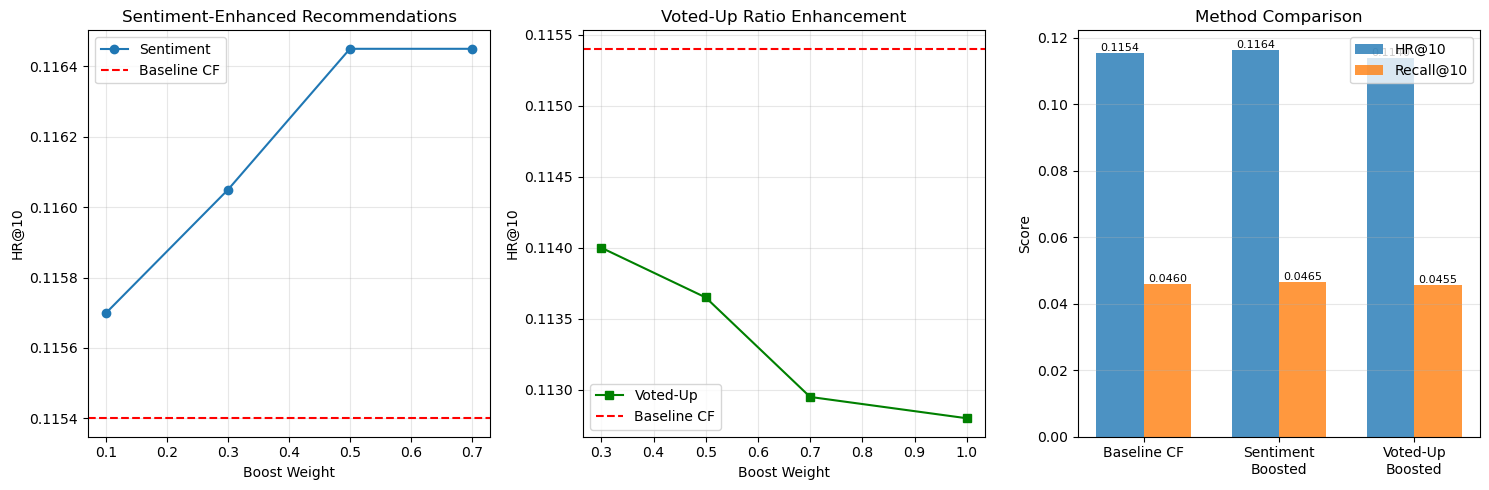

Final Summary
Baseline CF:           HR@10=0.115400, Recall@10=0.046031
Best Sentiment Boost:  HR@10=0.116450, Recall@10=0.046513 (weight=0.5)
Best Voted-Up Boost:   HR@10=0.114000, Recall@10=0.045530 (weight=0.3)


In [13]:
# Comparison of baseline vs sentiment vs voted-up
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Sentiment boost comparison
sentiment_df = pd.DataFrame(sentiment_results)
axes[0].plot(sentiment_df['boost_weight'], sentiment_df['HR@10'], marker='o', label='Sentiment')
axes[0].axhline(hr_base, color='r', linestyle='--', label='Baseline CF')
axes[0].set_xlabel('Boost Weight')
axes[0].set_ylabel('HR@10')
axes[0].set_title('Sentiment-Enhanced Recommendations')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Voted-up boost comparison
axes[1].plot(votedup_df['boost_weight'], votedup_df['HR@10'], marker='s', label='Voted-Up', color='green')
axes[1].axhline(hr_base, color='r', linestyle='--', label='Baseline CF')
axes[1].set_xlabel('Boost Weight')
axes[1].set_ylabel('HR@10')
axes[1].set_title('Voted-Up Ratio Enhancement')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Best of each vs baseline
best_sentiment = sentiment_df.loc[sentiment_df['HR@10'].idxmax()]
best_votedup = votedup_df.loc[votedup_df['HR@10'].idxmax()]

methods = ['Baseline CF', 'Sentiment\nBoosted', 'Voted-Up\nBoosted']
hr_scores = [hr_base, best_sentiment['HR@10'], best_votedup['HR@10']]
recall_scores = [rec_base, best_sentiment['Recall@10'], best_votedup['Recall@10']]

x = np.arange(len(methods))
width = 0.35

bars1 = axes[2].bar(x - width/2, hr_scores, width, label='HR@10', alpha=0.8)
bars2 = axes[2].bar(x + width/2, recall_scores, width, label='Recall@10', alpha=0.8)

axes[2].set_ylabel('Score')
axes[2].set_title('Method Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods)
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/text_features_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("Final Summary")
print(f"Baseline CF:           HR@10={hr_base:.6f}, Recall@10={rec_base:.6f}")
print(f"Best Sentiment Boost:  HR@10={best_sentiment['HR@10']:.6f}, Recall@10={best_sentiment['Recall@10']:.6f} (weight={best_sentiment['boost_weight']})")
print(f"Best Voted-Up Boost:   HR@10={best_votedup['HR@10']:.6f}, Recall@10={best_votedup['Recall@10']:.6f} (weight={best_votedup['boost_weight']})")

In [14]:
artifacts = {
    'model': model,
    'user2idx': user2idx,
    'item2idx': item2idx,
    'idx2item': idx2item,
    'train_items_by_user': train_items_by_user,
    'test_items_by_user': test_items_by_user,
    'X_train': X_train,
    'users_final': users_final,
    'avg_user_sentiment': avg_user_sentiment,
    'item_avg_sentiment': item_avg_sentiment,
    'item_positive_ratio': item_positive_ratio,
    'item_avg_helpfulness': item_avg_helpfulness,
    'user_sentiment_scores': user_sentiment_scores
}

save_path = f"{OUTPUT_DIR}/text_enhanced_model.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(artifacts, f)

file_size = os.path.getsize(save_path) / (1024**2)
print(f" Saved to: {save_path}")
print(f" File size: {file_size:.2f} MB")

 Saved to: /home/brocchio/teams/z2/text_features//text_enhanced_model.pkl
 File size: 25.49 MB


In [15]:
n_users = len(users_final)
n_items = len(item2idx)
n_train_reviews = sum(len(v) for v in train_items_by_user.values())
n_test_reviews = sum(len(v) for v in test_items_by_user.values())

In [16]:
#BERT-embedding

In [17]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "sentence-transformers", "--break-system-packages", "-q"
])


0

In [18]:
from sentence_transformers import SentenceTransformer
import torch

MODEL_NAME = 'paraphrase-MiniLM-L3-v2' 

print(f"Loading BERT: {MODEL_NAME}")
bert_model = SentenceTransformer(MODEL_NAME)


device = 'cpu'
bert_model = bert_model.to(device)

print(f" Model on CPU (safer for large datasets)")
print(f" Embedding dim: {bert_model.get_sentence_embedding_dimension()}")

# Test
test_review = "This game is absolutely amazing! Best purchase ever."
test_embedding = bert_model.encode(test_review, show_progress_bar=False)
print(f" Test embedding shape: {test_embedding.shape}")

2026-02-21 01:34:44.281586: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-21 01:34:44.281644: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-21 01:34:44.282953: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-21 01:34:44.289885: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading BERT: paraphrase-MiniLM-L3-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 Model on CPU (safer for large datasets)
 Embedding dim: 384
 Test embedding shape: (384,)


In [19]:
#Sampling: Reviews with 20+ characters to select more meaningful contents
MIN_REVIEW_LENGTH = 20
meaningful_reviews = []
review_metadata = []

for u in users_final:
    for rev_data in train_reviews_by_user[u]:
        review_text = rev_data['review_text']
        if review_text and len(review_text.strip()) >= MIN_REVIEW_LENGTH:
            meaningful_reviews.append(review_text)
            review_metadata.append({
                'user_id': u,
                'appid': rev_data['appid'],
                'review_text': review_text
            })

unique_reviews = list(set(meaningful_reviews))
print(f" {len(unique_reviews):,} unique reviews to embed")

del meaningful_reviews
gc.collect()

embedding_cache = load_checkpoint('embeddings_20k')

if embedding_cache is None:
    start_time = time.time()
    
    # CPU MODE
    BATCH_SIZE = 32
    CHUNK_SIZE = 10000
    device = 'cpu'
    print(f" CPU Mode: Batch size = {BATCH_SIZE}")
    
    # Generate embeddings on CPU
    all_embeddings = []

    for i in range(0, len(unique_reviews), CHUNK_SIZE):
        chunk = unique_reviews[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(unique_reviews)-1)//CHUNK_SIZE + 1}")
    
        chunk_embeddings = bert_model.encode(
            chunk,
            show_progress_bar=True,
            batch_size=BATCH_SIZE,
            device='cpu',
            convert_to_numpy=True,
            normalize_embeddings=True,
            convert_to_tensor=False
        )
        all_embeddings.extend(chunk_embeddings)

    embedding_cache = {review: emb for review, emb in zip(unique_reviews, all_embeddings)}
    
    elapsed = time.time() - start_time
    speed = len(embedding_cache) / elapsed
    
    print(f" Generated {len(embedding_cache):,} embeddings")
    print(f" Time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
    print(f" Speed: {speed:.0f} embeddings/second")
    
    save_checkpoint('embeddings_20k', embedding_cache)
else:
    print(f" Using {len(embedding_cache):,} embeddings from checkpoint")

embedding_dim = bert_model.get_sentence_embedding_dimension()
mem_mb = len(embedding_cache) * 384 * 4 / (1024**2)
print(f" RAM usage: {mem_mb:.0f} MB ({mem_mb/64000*100:.1f}% of 64GB)")

del unique_reviews
gc.collect()

 126,886 unique reviews to embed
 Loaded: embeddings_20k (in 0.5s)
 Using 126,886 embeddings from checkpoint
 RAM usage: 186 MB (0.3% of 64GB)


0

In [20]:
# Creating average BERT embedding per each item
item_review_embeddings = defaultdict(list)

# Collect embeddings for each item
for meta in tqdm(review_metadata, desc="Processing items"):
    review_text = meta['review_text']
    appid = meta['appid']
    
    if review_text in embedding_cache:
        item_review_embeddings[appid].append(embedding_cache[review_text])

# Average embeddings for each item
item_avg_bert = {}
for appid, embeddings in item_review_embeddings.items():
    item_avg_bert[appid] = np.mean(embeddings, axis=0)

print(f" Created BERT profiles for {len(item_avg_bert):,} items")

del item_review_embeddings
gc.collect()

# Save item embeddings
with open(f"{OUTPUT_DIR}/item_bert_embeddings_64gb.pkl", 'wb') as f:
    pickle.dump(item_avg_bert, f)
print(f" Saved item BERT embeddings")

Processing items: 100%|██████████| 128463/128463 [00:00<00:00, 935072.13it/s]


 Created BERT profiles for 15,065 items
 Saved item BERT embeddings


In [21]:
# Creating average BERT embedding per user
user_review_embeddings = defaultdict(list)

# Collect embeddings for each user
for meta in tqdm(review_metadata, desc="Processing users"):
    review_text = meta['review_text']
    user_id = meta['user_id']
    
    if review_text in embedding_cache:
        user_review_embeddings[user_id].append(embedding_cache[review_text])

# Average embeddings for each user
user_avg_bert = {}
for user_id, embeddings in user_review_embeddings.items():
    user_avg_bert[user_id] = np.mean(embeddings, axis=0)

print(f" Created BERT profiles for {len(user_avg_bert):,} users")

del user_review_embeddings
gc.collect()

with open(f"{OUTPUT_DIR}/user_bert_embeddings_64gb.pkl", 'wb') as f:
    pickle.dump(user_avg_bert, f)
print(f" Saved user BERT embeddings")


print(f"BERT Profile Summary:")
print(f"  Item BERT profiles: {len(item_avg_bert):,}")
print(f"  User BERT profiles: {len(user_avg_bert):,}")
print(f"  Review embeddings cached: {len(embedding_cache):,}")
print(f"  Coverage: {len(user_avg_bert)/len(users_final)*100:.1f}% of users have BERT profiles")

Processing users: 100%|██████████| 128463/128463 [00:00<00:00, 959535.69it/s]


 Created BERT profiles for 18,752 users
 Saved user BERT embeddings
BERT Profile Summary:
  Item BERT profiles: 15,065
  User BERT profiles: 18,752
  Review embeddings cached: 126,886
  Coverage: 93.8% of users have BERT profiles


In [22]:
# Recommendation using BERT semantic similarity
from sklearn.metrics.pairwise import cosine_similarity

def recommend_with_bert_boost(model, X_user_item, ui, user_id,
                               idx2item, user_avg_bert, item_avg_bert,
                               N=10, oversample=200, boost_weight=0.5):

    # Boost recommednations using BERT semantic simliarity, and users who write similar reviews should get similar game recommendations
    # Get ALS baseline recommendations
    ids, scores = model.recommend(
        np.array([ui]),
        X_user_item[[ui]],
        N=oversample,
        filter_already_liked_items=True
    )
    
    if user_id not in user_avg_bert:
        return [idx2item[int(i)] for i in ids[0][:N]]
    
    user_embedding = user_avg_bert[user_id].reshape(1, -1)
    
    # Calculation of BERT similarity and boost scores
    boosted_scores = scores[0].copy()
    
    for i, item_idx in enumerate(ids[0]):
        appid = idx2item[int(item_idx)]
        
        if appid in item_avg_bert:
            item_embedding = item_avg_bert[appid].reshape(1, -1)

            similarity = cosine_similarity(user_embedding, item_embedding)[0][0]
            normalized_sim = (similarity + 1) / 2
            boosted_scores[i] *= (1 + boost_weight * normalized_sim)
    
    # Ranking by updated boosted scores
    top_indices = np.argsort(-boosted_scores)[:N]
    return [idx2item[int(ids[0][i])] for i in top_indices]


# Evaluation function
def eval_bert_model(model, X_user_item, users_final, user2idx, idx2item,
                    test_items_by_user, user_avg_bert, item_avg_bert,
                    K=10, boost_weight=0.5):
    hits = total = hit_count = true_count = 0
    users_with_bert = 0

    for u in users_final:
        true = test_items_by_user.get(u, set())
        if not true:
            continue
        
        ui = int(user2idx[u])
        
        rec_items = recommend_with_bert_boost(
            model, X_user_item, ui, u, idx2item,
            user_avg_bert, item_avg_bert,
            N=K, boost_weight=boost_weight
        )
        
        if u in user_avg_bert:
            users_with_bert += 1
        
        inter = true & set(rec_items)
        if inter:
            hits += 1
        hit_count += len(inter)
        true_count += len(true)
        total += 1

    hr = hits / total if total else 0.0
    recall = hit_count / true_count if true_count else 0.0
    precision = hit_count / (total * K) if total else 0.0
    
    coverage = users_with_bert / total * 100 if total else 0
    print(f"  Users with BERT profiles: {users_with_bert}/{total} ({coverage:.1f}%)")
    
    return hr, recall, precision, total


# Testing out BERT boost

print(f"Baseline CF: HR@10={hr_base:.6f}, Recall@10={rec_base:.6f}\n")
boost_weights = [0.3, 0.5, 0.7, 1.0]
bert_results = []

for bw in boost_weights:
    print(f"Testing boost_weight={bw}")
    hr, rec, prec, n = eval_bert_model(
        model, X_train_csr, users_final, user2idx, idx2item,
        test_items_by_user, user_avg_bert, item_avg_bert,
        K=10, boost_weight=bw
    )
    
    bert_results.append({
        'boost_weight': bw,
        'HR@10': hr,
        'Recall@10': rec,
        'Precision@10': prec,
        'n_users': n
    })
    
    improvement_hr = ((hr - hr_base) / hr_base) * 100
    improvement_rec = ((rec - rec_base) / rec_base) * 100
    
    print(f"  HR@10:     {hr:.6f} ({improvement_hr:+.2f}% vs baseline)")
    print(f"  Recall@10: {rec:.6f} ({improvement_rec:+.2f}% vs baseline)")
    print()

# Save results
bert_df = pd.DataFrame(bert_results)
bert_df.to_csv(f"{OUTPUT_DIR}/bert_boost_results_64gb.csv", index=False)
print(f" Saved BERT results to {OUTPUT_DIR}/bert_boost_results_64gb.csv")

Baseline CF: HR@10=0.115400, Recall@10=0.046031

Testing boost_weight=0.3
  Users with BERT profiles: 18752/20000 (93.8%)
  HR@10:     0.115950 (+0.48% vs baseline)
  Recall@10: 0.046328 (+0.64% vs baseline)

Testing boost_weight=0.5
  Users with BERT profiles: 18752/20000 (93.8%)
  HR@10:     0.115850 (+0.39% vs baseline)
  Recall@10: 0.046309 (+0.60% vs baseline)

Testing boost_weight=0.7
  Users with BERT profiles: 18752/20000 (93.8%)
  HR@10:     0.116100 (+0.61% vs baseline)
  Recall@10: 0.046420 (+0.85% vs baseline)

Testing boost_weight=1.0
  Users with BERT profiles: 18752/20000 (93.8%)
  HR@10:     0.116200 (+0.69% vs baseline)
  Recall@10: 0.046439 (+0.89% vs baseline)

 Saved BERT results to /home/brocchio/teams/z2/text_features//bert_boost_results_64gb.csv


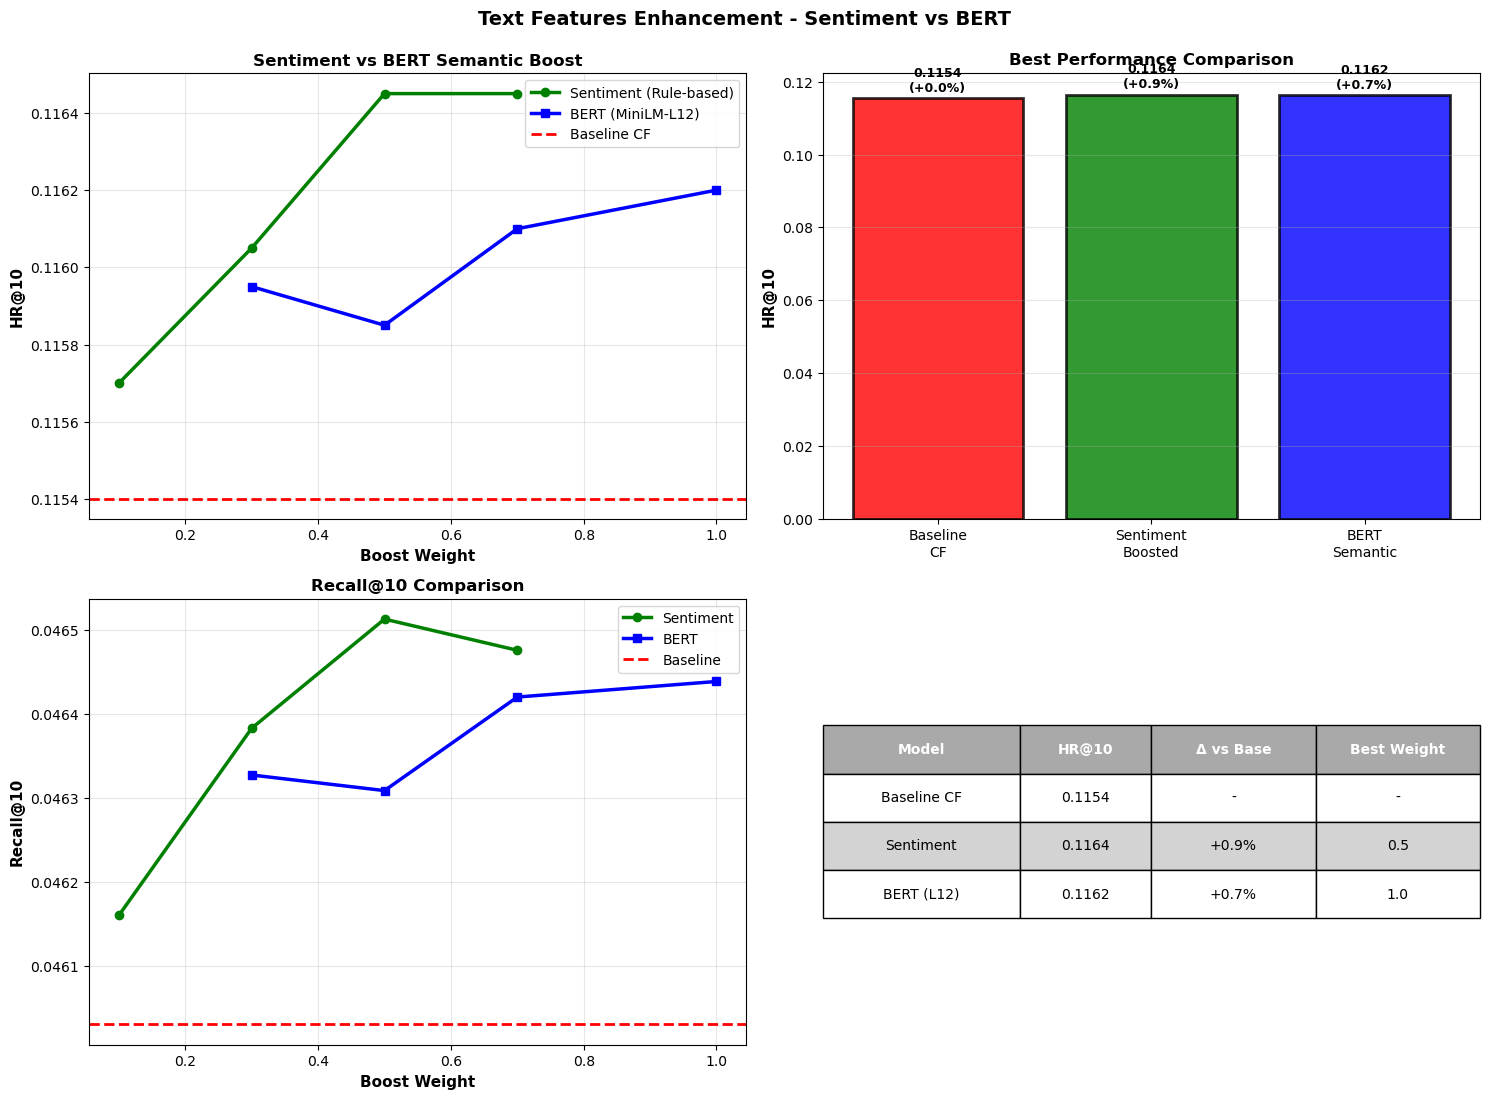

Final Results Summary
Baseline CF:              HR@10 = 0.115400
Best Sentiment:           HR@10 = 0.116450 (+0.91%)
Best BERT (MiniLM-L12):   HR@10 = 0.116200 (+0.69%)


In [23]:
# Comprehensive comparison and Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Sentiment vs BERT
sentiment_df = pd.DataFrame(sentiment_results)
bert_df = pd.DataFrame(bert_results)

axes[0, 0].plot(sentiment_df['boost_weight'], sentiment_df['HR@10'], 
               marker='o', linewidth=2.5, label='Sentiment (Rule-based)', color='green')
axes[0, 0].plot(bert_df['boost_weight'], bert_df['HR@10'], 
               marker='s', linewidth=2.5, label='BERT (MiniLM-L12)', color='blue')
axes[0, 0].axhline(hr_base, color='red', linestyle='--', linewidth=2, label='Baseline CF')
axes[0, 0].set_xlabel('Boost Weight', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('HR@10', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Sentiment vs BERT Semantic Boost', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Best of each method
best_sentiment = sentiment_df.loc[sentiment_df['HR@10'].idxmax()]
best_bert = bert_df.loc[bert_df['HR@10'].idxmax()]

methods = ['Baseline\nCF', 'Sentiment\nBoosted', 'BERT\nSemantic']
hr_scores = [hr_base, best_sentiment['HR@10'], best_bert['HR@10']]
colors = ['red', 'green', 'blue']

bars = axes[0, 1].bar(methods, hr_scores, color=colors, alpha=0.8, 
                      edgecolor='black', linewidth=2)

for bar, score in zip(bars, hr_scores):
    height = bar.get_height()
    improvement = ((score - hr_base) / hr_base) * 100 if score != hr_base else 0
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, height + 0.001,
                   f'{score:.4f}\n(+{improvement:.1f}%)', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0, 1].set_ylabel('HR@10', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Best Performance Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Recall comparison
axes[1, 0].plot(sentiment_df['boost_weight'], sentiment_df['Recall@10'], 
               marker='o', linewidth=2.5, label='Sentiment', color='green')
axes[1, 0].plot(bert_df['boost_weight'], bert_df['Recall@10'], 
               marker='s', linewidth=2.5, label='BERT', color='blue')
axes[1, 0].axhline(rec_base, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1, 0].set_xlabel('Boost Weight', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Recall@10', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Recall@10 Comparison', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Comparison table
ax_table = axes[1, 1]
ax_table.axis('off')

comparison_data = [
    ['Model', 'HR@10', 'Δ vs Base', 'Best Weight'],
    ['Baseline CF', f"{hr_base:.4f}", '-', '-'],
    ['Sentiment', f"{best_sentiment['HR@10']:.4f}", 
     f"+{((best_sentiment['HR@10']-hr_base)/hr_base)*100:.1f}%", 
     f"{best_sentiment['boost_weight']:.1f}"],
    ['BERT (L12)', f"{best_bert['HR@10']:.4f}", 
     f"+{((best_bert['HR@10']-hr_base)/hr_base)*100:.1f}%", 
     f"{best_bert['boost_weight']:.1f}"]
]

table = ax_table.table(cellText=comparison_data, cellLoc='center', loc='center',
                      colWidths=[0.3, 0.2, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

for i in range(4):
    table[(0, i)].set_facecolor('darkgray')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, 4):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('lightgray')

plt.suptitle('Text Features Enhancement - Sentiment vs BERT', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bert_complete_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


print("Final Results Summary")
print("="*70)
print(f"Baseline CF:              HR@10 = {hr_base:.6f}")
print(f"Best Sentiment:           HR@10 = {best_sentiment['HR@10']:.6f} (+{((best_sentiment['HR@10']-hr_base)/hr_base)*100:.2f}%)")
print(f"Best BERT (MiniLM-L12):   HR@10 = {best_bert['HR@10']:.6f} (+{((best_bert['HR@10']-hr_base)/hr_base)*100:.2f}%)")



In [24]:
bert_artifacts = {
    'model': model,
    'user2idx': user2idx,
    'item2idx': item2idx,
    'idx2item': idx2item,
    'train_items_by_user': train_items_by_user,
    'test_items_by_user': test_items_by_user,
    'X_train': X_train,
    'users_final': users_final,
    
    # Sentiment features (original)
    'avg_user_sentiment': avg_user_sentiment,
    'item_avg_sentiment': item_avg_sentiment,
    'item_positive_ratio': item_positive_ratio,
    
    # BERT features (new)
    'user_avg_bert': user_avg_bert,
    'item_avg_bert': item_avg_bert,
    'embedding_cache': embedding_cache,
    
    # Best configurations
    'best_sentiment_weight': float(best_sentiment['boost_weight']),
    'best_bert_weight': float(best_bert['boost_weight']),
    
    # Results for reference
    'sentiment_results': sentiment_results,
    'bert_results': bert_results,
    'baseline_hr': hr_base,
    'baseline_recall': rec_base
}

save_path = f"{OUTPUT_DIR}/bert_enhanced_model_full.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(bert_artifacts, f)

file_size = os.path.getsize(save_path) / (1024**2)

print(f" Saved complete BERT-enhanced model")
print(f"  Location: {save_path}")
print(f"  File size: {file_size:.2f} MB")
print(f"  Artifacts include:")
print(f"  - Trained ALS model")
print(f"  - User/Item mappings ({len(user2idx):,} users, {len(item2idx):,} items)")
print(f"  - Sentiment features")
print(f"  - BERT embeddings ({len(embedding_cache):,} reviews)")
print(f"  - Best configurations (sentiment={bert_artifacts['best_sentiment_weight']}, bert={bert_artifacts['best_bert_weight']})")
print(f"  - All evaluation results")

 Saved complete BERT-enhanced model
  Location: /home/brocchio/teams/z2/text_features//bert_enhanced_model_full.pkl
  File size: 306.67 MB
  Artifacts include:
  - Trained ALS model
  - User/Item mappings (20,000 users, 16,388 items)
  - Sentiment features
  - BERT embeddings (126,886 reviews)
  - Best configurations (sentiment=0.5, bert=1.0)
  - All evaluation results


## Addition of ALS by Brandon

In [25]:
# NEW: Positive-only interactions (voted_up == True)
train_items_by_user_pos = {
    u: [r["appid"] for r in revs if r.get("voted_up", False)]
    for u, revs in train_reviews_by_user.items()
}

test_items_by_user_pos = {
    u: {r["appid"] for r in revs if r.get("voted_up", False)}
    for u, revs in test_reviews_by_user.items()
}

# NEW: Users that still have at least 1 positive train + 1 positive test after filtering
users_final_pos = [
    u for u in users_final
    if len(train_items_by_user_pos.get(u, [])) > 0 and len(test_items_by_user_pos.get(u, set())) > 0
]

print("users_final (original):", len(users_final))
print("users_final_pos (voted_up only):", len(users_final_pos))


users_final (original): 20000
users_final_pos (voted_up only): 18768


In [26]:
import numpy as np
import scipy.sparse as sp

# NEW: CSR built only from voted_up positives
rows, cols, data = [], [], []

for u in users_final_pos:
    ui = user2idx.get(u)
    if ui is None:
        continue
    for appid in train_items_by_user_pos.get(u, []):
        ii = item2idx.get(appid)
        if ii is None:
            continue
        rows.append(ui)
        cols.append(ii)
        data.append(1.0)

X_user_item_pos = sp.csr_matrix(
    (data, (rows, cols)),
    shape=X_train_csr.shape,   # keep identical shape (users x items) 
    dtype=np.float32
)

# implicit commonly fits on item-user
X_item_user_pos = X_user_item_pos.T.tocsr()

print("X_train_csr (original):", X_train_csr.shape, "nnz=", X_train_csr.nnz)
print("X_user_item_pos (new): ", X_user_item_pos.shape, "nnz=", X_user_item_pos.nnz)


X_train_csr (original): (20000, 16388) nnz= 177884
X_user_item_pos (new):  (20000, 16388) nnz= 147742


In [36]:
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight

def fit_raw_als_user_item(X_user_item, factors, reg, alpha, iterations,
                          random_state=42, num_threads=0):
    m = AlternatingLeastSquares(
        factors=factors,
        regularization=reg,
        iterations=iterations,
        random_state=random_state,
        num_threads=num_threads,
    )
    # IMPORTANT: fit expects (users x items) in THIS notebook setup
    m.fit((X_user_item * alpha).tocsr())
    return m

def fit_bm25_als_user_item(X_user_item, factors, reg, alpha, iterations,
                           K1, B, random_state=42, num_threads=0):
    X_bm_user_item = bm25_weight(X_user_item, K1=K1, B=B).tocsr()
    m = AlternatingLeastSquares(
        factors=factors,
        regularization=reg,
        iterations=iterations,
        random_state=random_state,
        num_threads=num_threads,
    )
    # Still (users x items)
    m.fit((X_bm_user_item * alpha).tocsr())
    return m, X_bm_user_item

In [37]:
ALS_TUNED_CFG = {"factors": 16, "reg": 0.01, "alpha": 20, "iterations": 20}
BM25_TUNED_CFG = {"K1": 0.5, "B": 0.75}

m_als_pos_tuned = fit_raw_als_user_item(X_user_item_pos, **ALS_TUNED_CFG)
m_bm25_pos_tuned, X_bm25_user_item_pos = fit_bm25_als_user_item(
    X_user_item_pos, **ALS_TUNED_CFG, **BM25_TUNED_CFG
)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
print("X_user_item_pos:", X_user_item_pos.shape)
print("idx2item:", len(idx2item), "max:", max(idx2item))
print("ALS item_factors:", m_als_pos_tuned.item_factors.shape)
print("ALS user_factors:", m_als_pos_tuned.user_factors.shape)

X_user_item_pos: (20000, 16388)
idx2item: 16388 max: 16387
ALS item_factors: (16388, 16)
ALS user_factors: (20000, 16)


In [40]:
K = 10
hr_als_pos, rec_als_pos, prec_als_pos, n_als_pos = eval_model(
    m_als_pos_tuned,
    X_user_item_pos,
    users_final_pos,
    user2idx,
    idx2item,
    test_items_by_user_pos,
    K=K
)

hr_bm25_pos, rec_bm25_pos, prec_bm25_pos, n_bm25_pos = eval_model(
    m_bm25_pos_tuned,
    X_bm25_user_item_pos,   # use the bm25-weighted user×item matrix here
    users_final_pos,
    user2idx,
    idx2item,
    test_items_by_user_pos,
    K=K
)

print(f"ALS (pos-only tuned):      HR@{K}={hr_als_pos:.6f} Recall@{K}={rec_als_pos:.6f} Prec@{K}={prec_als_pos:.6f} users={n_als_pos}")
print(f"BM25+ALS (pos-only tuned): HR@{K}={hr_bm25_pos:.6f} Recall@{K}={rec_bm25_pos:.6f} Prec@{K}={prec_bm25_pos:.6f} users={n_bm25_pos}")

ALS (pos-only tuned):      HR@10=0.177962 Recall@10=0.080877 Prec@10=0.019331 users=18768
BM25+ALS (pos-only tuned): HR@10=0.191816 Recall@10=0.087766 Prec@10=0.020977 users=18768


In [47]:
import os
import pickle
from datetime import datetime

# Create directory if needed
MODEL_DIR = os.path.join(os.getcwd(), "saved_models")
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_model_bundle(model, name, extra_objects=None):
    bundle = {
        "model": model,
        "user2idx": user2idx,
        "idx2item": idx2item,
        "n_users": X_user_item_pos.shape[0],
        "n_items": X_user_item_pos.shape[1],
    }
    
    if extra_objects:
        bundle.update(extra_objects)

    path = os.path.join(MODEL_DIR, f"{name}_{timestamp}.pkl")
    
    with open(path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f"Saved: {path}")
    print(f"  Users: {bundle['n_users']}")
    print(f"  Items: {bundle['n_items']}")
    print("-"*60)

# Save ALS
save_model_bundle(
    m_als_pos_tuned,
    name="als_pos_only",
    extra_objects={"recall": rec_als_pos, "hr": hr_als_pos}
)

# Save BM25+ALS
save_model_bundle(
    m_bm25_pos_tuned,
    name="bm25_als_pos_only",
    extra_objects={
        "recall": rec_bm25_pos,
        "hr": hr_bm25_pos
    }
)

Saved: /home/brocchio/teams/z2/data/steam/notebooks/saved_models/als_pos_only_20260221_034938.pkl
  Users: 20000
  Items: 16388
------------------------------------------------------------
Saved: /home/brocchio/teams/z2/data/steam/notebooks/saved_models/bm25_als_pos_only_20260221_034938.pkl
  Users: 20000
  Items: 16388
------------------------------------------------------------


In [41]:
import numpy as np

def coverage_report(model, X_user_item, users_final, user2idx, idx2item, test_items_by_user, K=10, overfetch_mult=5):
    n_items = X_user_item.shape[1]
    n_users = len(users_final)

    users_with_k = 0
    users_with_any = 0
    users_with_hit = 0

    all_recommended_items = set()
    total_recs_emitted = 0

    for u in users_final:
        if u not in user2idx:
            continue

        ui = int(user2idx[u])

        # Overfetch then filter to ensure we still get K mapped items
        N = min(n_items, K * overfetch_mult)
        ids, scores = model.recommend(
            np.array([ui]),
            X_user_item[ui],
            N=N,
            filter_already_liked_items=True
        )

        rec_list = []
        for i in ids[0]:
            ii = int(i)
            # guard: only keep items that exist in idx2item
            if 0 <= ii < n_items and ii in idx2item:
                rec_list.append(idx2item[ii])
            if len(rec_list) == K:
                break

        rec_set = set(rec_list)

        if len(rec_set) > 0:
            users_with_any += 1
        if len(rec_set) >= K:
            users_with_k += 1

        total_recs_emitted += len(rec_set)
        all_recommended_items.update(rec_set)

        # hit coverage (>=1 test item in recs)
        true_items = test_items_by_user.get(u, set())
        if true_items and (len(rec_set & true_items) > 0):
            users_with_hit += 1

    catalog_coverage = len(all_recommended_items) / max(1, len(idx2item))
    avg_recs = total_recs_emitted / max(1, n_users)

    return {
        "n_users_eval": n_users,
        "user_cov_any": users_with_any / max(1, n_users),
        "user_cov_atK": users_with_k / max(1, n_users),
        "hit_cov": users_with_hit / max(1, n_users),
        "unique_items_recommended": len(all_recommended_items),
        "catalog_cov": catalog_coverage,
        "avg_recs_returned": avg_recs,
    }

In [42]:
K = 10

als_cov = coverage_report(
    m_als_pos_tuned,
    X_user_item_pos,
    users_final_pos,
    user2idx,
    idx2item,
    test_items_by_user_pos,
    K=K
)

bm25_cov = coverage_report(
    m_bm25_pos_tuned,
    X_bm25_user_item_pos,
    users_final_pos,
    user2idx,
    idx2item,
    test_items_by_user_pos,
    K=K
)

als_cov, bm25_cov

({'n_users_eval': 18768,
  'user_cov_any': 1.0,
  'user_cov_atK': 1.0,
  'hit_cov': 0.1779624893435635,
  'unique_items_recommended': 299,
  'catalog_cov': 0.018245057359043203,
  'avg_recs_returned': 10.0},
 {'n_users_eval': 18768,
  'user_cov_any': 1.0,
  'user_cov_atK': 1.0,
  'hit_cov': 0.1918158567774936,
  'unique_items_recommended': 663,
  'catalog_cov': 0.04045643153526971,
  'avg_recs_returned': 10.0})

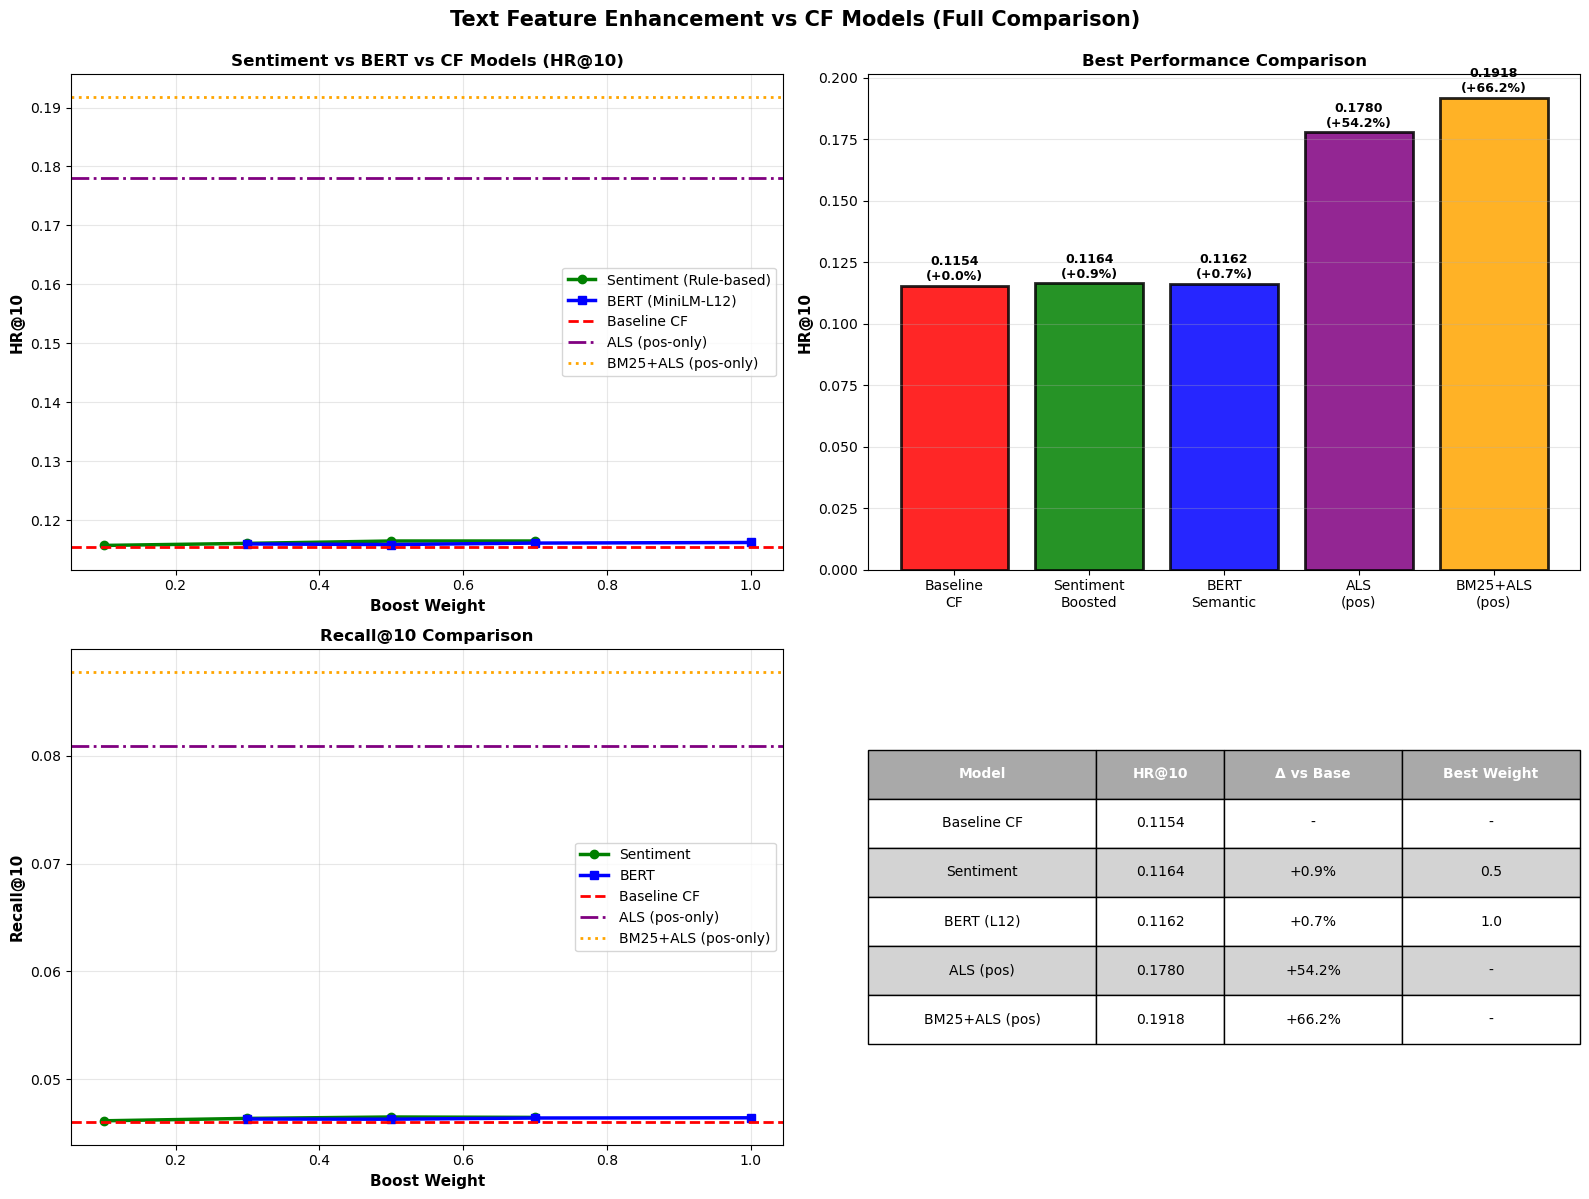

Final Results Summary
Baseline CF:              HR@10 = 0.115400
ALS (pos-only):           HR@10 = 0.177962 (+54.21%)
BM25+ALS (pos-only):      HR@10 = 0.191816 (+66.22%)
Best Sentiment:           HR@10 = 0.116450 (+0.91%)
Best BERT (MiniLM-L12):   HR@10 = 0.116200 (+0.69%)


In [46]:
# COMPLETE COMPARISON CELL

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Convert results to DataFrames
sentiment_df = pd.DataFrame(sentiment_results)
bert_df = pd.DataFrame(bert_results)

# Plot 1: HR@10 vs Boost
axes[0, 0].plot(sentiment_df['boost_weight'], sentiment_df['HR@10'],
               marker='o', linewidth=2.5, label='Sentiment (Rule-based)', color='green')

axes[0, 0].plot(bert_df['boost_weight'], bert_df['HR@10'],
               marker='s', linewidth=2.5, label='BERT (MiniLM-L12)', color='blue')

axes[0, 0].axhline(hr_base, color='red', linestyle='--', linewidth=2, label='Baseline CF')
axes[0, 0].axhline(hr_als_pos, color='purple', linestyle='-.', linewidth=2, label='ALS (pos-only)')
axes[0, 0].axhline(hr_bm25_pos, color='orange', linestyle=':', linewidth=2, label='BM25+ALS (pos-only)')

axes[0, 0].set_xlabel('Boost Weight', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('HR@10', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Sentiment vs BERT vs CF Models (HR@10)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Best Model Comparison (Bar Chart)
best_sentiment = sentiment_df.loc[sentiment_df['HR@10'].idxmax()]
best_bert = bert_df.loc[bert_df['HR@10'].idxmax()]

methods = [
    'Baseline\nCF',
    'Sentiment\nBoosted',
    'BERT\nSemantic',
    'ALS\n(pos)',
    'BM25+ALS\n(pos)'
]

hr_scores = [
    hr_base,
    best_sentiment['HR@10'],
    best_bert['HR@10'],
    hr_als_pos,
    hr_bm25_pos
]

colors = ['red', 'green', 'blue', 'purple', 'orange']

bars = axes[0, 1].bar(methods, hr_scores, color=colors,
                      alpha=0.85, edgecolor='black', linewidth=2)

for bar, score in zip(bars, hr_scores):
    height = bar.get_height()
    improvement = ((score - hr_base) / hr_base) * 100 if score != hr_base else 0
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f'{score:.4f}\n(+{improvement:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

axes[0, 1].set_ylabel('HR@10', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Best Performance Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Recall@10 vs Boost
axes[1, 0].plot(sentiment_df['boost_weight'], sentiment_df['Recall@10'],
               marker='o', linewidth=2.5, label='Sentiment', color='green')

axes[1, 0].plot(bert_df['boost_weight'], bert_df['Recall@10'],
               marker='s', linewidth=2.5, label='BERT', color='blue')

axes[1, 0].axhline(rec_base, color='red', linestyle='--', linewidth=2, label='Baseline CF')
axes[1, 0].axhline(rec_als_pos, color='purple', linestyle='-.', linewidth=2, label='ALS (pos-only)')
axes[1, 0].axhline(rec_bm25_pos, color='orange', linestyle=':', linewidth=2, label='BM25+ALS (pos-only)')

axes[1, 0].set_xlabel('Boost Weight', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Recall@10', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Recall@10 Comparison', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Comparison Table
ax_table = axes[1, 1]
ax_table.axis('off')

comparison_data = [
    ['Model', 'HR@10', 'Δ vs Base', 'Best Weight'],
    ['Baseline CF', f"{hr_base:.4f}", '-', '-'],
    ['Sentiment', f"{best_sentiment['HR@10']:.4f}",
     f"+{((best_sentiment['HR@10']-hr_base)/hr_base)*100:.1f}%",
     f"{best_sentiment['boost_weight']:.1f}"],
    ['BERT (L12)', f"{best_bert['HR@10']:.4f}",
     f"+{((best_bert['HR@10']-hr_base)/hr_base)*100:.1f}%",
     f"{best_bert['boost_weight']:.1f}"],
    ['ALS (pos)', f"{hr_als_pos:.4f}",
     f"+{((hr_als_pos-hr_base)/hr_base)*100:.1f}%",
     '-'],
    ['BM25+ALS (pos)', f"{hr_bm25_pos:.4f}",
     f"+{((hr_bm25_pos-hr_base)/hr_base)*100:.1f}%",
     '-']
]

table = ax_table.table(cellText=comparison_data,
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.32, 0.18, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

n_rows = len(comparison_data)
n_cols = len(comparison_data[0])

# Header styling
for j in range(n_cols):
    table[(0, j)].set_facecolor('darkgray')
    table[(0, j)].set_text_props(weight='bold', color='white')

# Alternate row shading
for i in range(1, n_rows):
    for j in range(n_cols):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('lightgray')

plt.suptitle('Text Feature Enhancement vs CF Models (Full Comparison)',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/complete_model_comparison.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Final Summary Print
print("Final Results Summary")
print("="*75)
print(f"Baseline CF:              HR@10 = {hr_base:.6f}")
print(f"ALS (pos-only):           HR@10 = {hr_als_pos:.6f} (+{((hr_als_pos-hr_base)/hr_base)*100:.2f}%)")
print(f"BM25+ALS (pos-only):      HR@10 = {hr_bm25_pos:.6f} (+{((hr_bm25_pos-hr_base)/hr_base)*100:.2f}%)")
print(f"Best Sentiment:           HR@10 = {best_sentiment['HR@10']:.6f} (+{((best_sentiment['HR@10']-hr_base)/hr_base)*100:.2f}%)")
print(f"Best BERT (MiniLM-L12):   HR@10 = {best_bert['HR@10']:.6f} (+{((best_bert['HR@10']-hr_base)/hr_base)*100:.2f}%)")